<a href="https://colab.research.google.com/github/lovnishverma/crop-p/blob/main/Crop_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [4]:
df = pd.read_csv("https://raw.githubusercontent.com/lovnishverma/datasets/refs/heads/main/Crop.csv")

In [5]:
df.head()

,N,P,K,ph,EC,S,Cu,Fe,Mn,Zn,B,label
0,143,69,217,5.9,0.58,0.23,10.20,116.35,59.96,54.85,21.29,pomegranate
1,170,36,216,5.9,0.15,0.28,15.69,114.20,56.87,31.28,28.62,pomegranate
2,158,66,219,6.8,0.34,0.20,15.29,65.87,51.81,57.12,27.59,pomegranate
3,133,45,207,6.4,0.94,0.21,8.48,103.10,43.81,68.50,47.29,pomegranate
4,132,48,218,6.7,0.54,0.19,5.59,63.40,56.40,46.71,31.04,pomegranate


ecoding is required if any of the features consist categorical (non-numerical) data

Scaling you can also do

In [6]:
df['label'].value_counts()

,count
label,
pomegranate,104
mango,104
grapes,104
mulberry,104
ragi,104
potato,100


In [17]:
df.describe()

,N,P,K,ph,EC,S,Cu,Fe,Mn,Zn,B
count,620.000000,620.000000,620.000000,620.000000,620.000000,620.000000,620.000000,620.000000,620.000000,620.000000,620.000000
mean,135.701613,52.508065,161.401613,6.106290,0.885468,0.484085,17.315452,117.212500,219.905887,34.340839,28.750710
std,31.808083,24.673538,81.285780,0.693782,0.637214,5.775388,6.441150,62.775199,341.998793,11.543871,19.636447
min,30.000000,10.000000,51.000000,4.500000,0.010000,0.011100,0.180000,3.810000,20.580000,17.990000,1.020000
25%,116.000000,30.000000,89.000000,5.700000,0.297500,0.086000,12.592500,68.312500,58.785000,24.727500,13.442500
50%,138.000000,54.000000,157.500000,6.100000,0.780000,0.168000,16.910000,108.245000,73.580000,31.425000,23.225000
75%,160.000000,75.000000,206.000000,6.500000,1.390000,0.240000,21.102500,155.620000,163.665000,43.542500,42.767500
max,198.000000,100.000000,369.000000,8.000000,2.480000,113.200000,35.000000,276.720000,1572.540000,70.000000,74.560000


After Data Cleaning and Data Pre-processing



---



Step 1: Import libraries and load data

In [8]:
import pandas as pd

In [9]:
df = pd.read_csv("https://raw.githubusercontent.com/lovnishverma/datasets/refs/heads/main/Crop.csv")

Step 2: Separate Target and Features

In [10]:
df.columns

Index(['N', 'P', 'K', 'ph', 'EC', 'S', 'Cu', 'Fe', 'Mn', 'Zn', 'B', 'label'], dtype='object')

In [11]:
X = [['N', 'P', 'K', 'ph', 'EC', 'S', 'Cu', 'Fe', 'Mn', 'Zn', 'B']] # Features

y = ['label'] # Target

or (using slicing)

In [14]:
X = df.iloc[:,:-1] # rows, Column

y = df.iloc[:,-1]

In [15]:
y

,label
0,pomegranate
1,pomegranate
2,pomegranate
3,pomegranate
4,pomegranate
...,...
615,potato
616,potato
617,potato
618,potato


Step 2: Test/train split for model evaluation

In [16]:
from sklearn.model_selection import train_test_split

In [18]:
# test train split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
X_train.describe()

,N,P,K,ph,EC,S,Cu,Fe,Mn,Zn,B
count,496.000000,496.000000,496.000000,496.000000,496.000000,496.000000,496.000000,496.000000,496.000000,496.000000,496.000000
mean,136.477823,52.500000,162.705645,6.114919,0.881794,0.565803,17.207460,118.600242,221.061008,34.457440,28.709355
std,31.688055,24.274607,81.627919,0.694407,0.628641,6.455623,6.447591,63.377239,344.385068,11.706243,19.783541
min,30.000000,10.000000,51.000000,4.500000,0.010000,0.011100,0.180000,3.810000,20.580000,17.990000,1.020000
25%,116.000000,30.000000,90.750000,5.700000,0.310000,0.087087,12.592500,69.125000,59.505000,25.032500,13.167500
50%,139.000000,53.000000,157.500000,6.100000,0.780000,0.167500,16.745000,108.945000,73.580000,31.230000,23.225000
75%,161.000000,74.250000,207.000000,6.500000,1.375000,0.240000,21.315000,157.287500,167.945000,43.542500,43.635000
max,198.000000,99.000000,369.000000,8.000000,2.480000,113.200000,35.000000,276.720000,1572.540000,70.000000,74.150000


Step 3: fit the model

In [27]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

Step 4: Model Evaluation

In [29]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [30]:
# accuracy

y_pred = model.predict(X_test)

accuracy_score(y_test, y_pred)

0.9758064516129032

In [31]:
# classification report

classification_report = classification_report(y_test, y_pred)

print(classification_report)

              precision    recall  f1-score   support

      grapes       0.96      0.96      0.96        24
       mango       0.94      0.94      0.94        18
    mulberry       1.00      1.00      1.00        21
 pomegranate       1.00      0.95      0.98        22
      potato       1.00      1.00      1.00        23
        ragi       0.94      1.00      0.97        16

    accuracy                           0.98       124
   macro avg       0.97      0.98      0.97       124
weighted avg       0.98      0.98      0.98       124



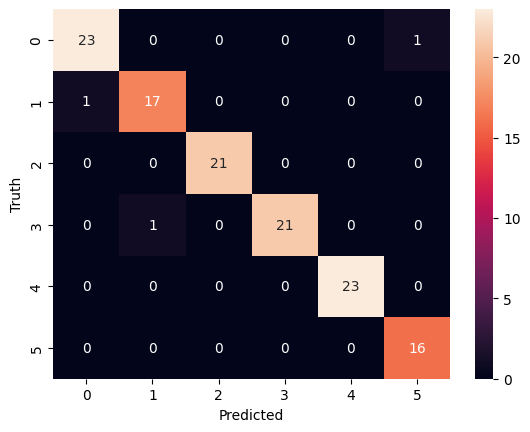

In [33]:
# confusion matrix using matplotlib

import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.show()

#################################

---



In [36]:
prediction = model.predict([[158,66,219,6.8,0.34,0.2,15.29,65.87,51.81,57.12,27.59]])

print(f'Predicted Crop is: {prediction[0]}')

Predicted Crop is: pomegranate


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [38]:
import joblib

# save model

joblib.dump(model, 'crop_model.joblib')

['crop_model.joblib']

In [39]:
# load model

model_loaded = joblib.load('crop_model.joblib')

In [40]:
prediction = model_loaded.predict([[158,66,219,6.8,0.34,0.2,15.29,65.87,51.81,57.12,27.59]])

print(f'Predicted Crop is: {prediction[0]}')

Predicted Crop is: pomegranate


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
